In [23]:
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from collections import Counter

# ── 1. Load embeddings ──────────────────────────────────────────────────────
CNN_PATH   = r"E:\Final_Year_Project\outputs\features\image_embeddings.npy"
GRAPH_PATH = r"E:\Final_Year_Project\outputs\gnn_features\tumor_graph_embeddings.npy"

cnn_embeddings   = np.load(CNN_PATH)
graph_embeddings = np.load(GRAPH_PATH)

print("CNN shape:",   cnn_embeddings.shape)
print("Graph shape:", graph_embeddings.shape)

# ── 2. Load paths and extract metadata ─────────────────────────────────────
DATASET_PATH = r"E:\Final_Year_Project\data\raw\breakhis\BreaKHis_v1\histology_slides\breast"

image_paths    = []
binary_labels  = []
subtype_labels = []
magnification  = []

MAG_MAP = {"40X": 40, "100X": 100, "200X": 200, "400X": 400}

# Refined aggressiveness mapping with clinical justification
AGGRESSIVENESS = {
    "A":  "Indolent-like",    # Adenosis — benign, very low risk
    "F":  "Indolent-like",    # Fibroadenoma — benign, common
    "TA": "Indolent-like",    # Tubular Adenoma — benign, well-differentiated
    "PT": "Moderate-like",    # Phyllodes Tumour — borderline, can recur
    "MC": "Moderate-like",    # Mucinous Carcinoma — malignant, better prognosis
    "DC": "Aggressive-like",  # Ductal Carcinoma — most aggressive, common
    "LC": "Aggressive-like",  # Lobular Carcinoma — aggressive, invasive
    "PC": "Aggressive-like",  # Papillary Carcinoma — aggressive
}

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            full_path = os.path.join(root, file)
            image_paths.append(full_path)

            binary_labels.append(
                0 if "benign" in root.lower() else 1
            )

            # Extract subtype from path
            subtype = "Unknown"
            for st in AGGRESSIVENESS:
                if f"_{st}-" in root or f"_{st}_" in root:
                    subtype = st
                    break
            subtype_labels.append(subtype)

            mag = 0
            for m_str, m_val in MAG_MAP.items():
                if m_str in root or m_str in file:
                    mag = m_val
                    break
            magnification.append(mag)

# Sort to match embedding order
combined = sorted(zip(image_paths, binary_labels, subtype_labels, magnification))
image_paths, binary_labels, subtype_labels, magnification = zip(*combined)

binary_labels  = np.array(binary_labels)
magnification  = np.array(magnification, dtype=np.float32)
subtype_labels = list(subtype_labels)

print("\nSubtype distribution:")
print(Counter(subtype_labels))

phenotype_labels = np.array([
    AGGRESSIVENESS.get(st, "Moderate-like") for st in subtype_labels
])

print("\nPhenotype distribution:")
print(Counter(phenotype_labels.tolist()))

CNN shape: (7909, 512)
Graph shape: (7909, 64)

Subtype distribution:
Counter({'DC': 3451, 'F': 1014, 'MC': 792, 'LC': 626, 'TA': 569, 'PC': 560, 'PT': 453, 'A': 444})

Phenotype distribution:
Counter({'Aggressive-like': 4637, 'Indolent-like': 2027, 'Moderate-like': 1245})


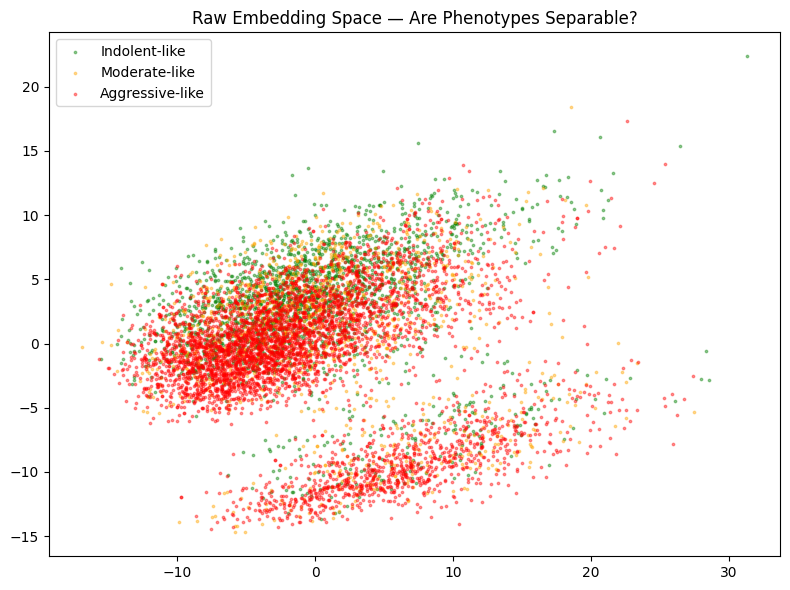


Enriched feature matrix shape: (7909, 590)
Normalized 1995 samples at 40X
Normalized 2081 samples at 100X
Normalized 2013 samples at 200X
Normalized 1820 samples at 400X

PCA output shape: (7909, 283)
Components kept: 283

Class mapping: {np.str_('Aggressive-like'): 0, np.str_('Indolent-like'): 1, np.str_('Moderate-like'): 2}
Class distribution: Counter({0: 4637, 1: 2027, 2: 1245})

=== Classifier Comparison (5-Fold CV) ===
Random Forest             | F1-macro: 37.71% ± 0.43%



KeyboardInterrupt



In [24]:
X_raw = np.hstack([cnn_embeddings, graph_embeddings]).astype(np.float32)

scaler_diag = StandardScaler()
X_diag = scaler_diag.fit_transform(X_raw)

pca_diag = PCA(n_components=2, random_state=42)
X_2d_diag = pca_diag.fit_transform(X_diag)

color_map = {
    "Indolent-like":   "green",
    "Moderate-like":   "orange",
    "Aggressive-like": "red"
}

plt.figure(figsize=(8, 6))
for ph, color in color_map.items():
    mask = phenotype_labels == ph
    plt.scatter(X_2d_diag[mask, 0], X_2d_diag[mask, 1],
                c=color, label=ph, s=3, alpha=0.4)
plt.title("Raw Embedding Space — Are Phenotypes Separable?")
plt.legend()
plt.tight_layout()
plt.show()

# ── 4. Engineer morphological features from GNN embeddings ─────────────────
# Your GNN embedding (64-dim) encodes cell structure
# Compute explicit discriminative statistics from it

gnn_mean   = graph_embeddings.mean(axis=1, keepdims=True)
gnn_std    = graph_embeddings.std(axis=1, keepdims=True)
gnn_max    = graph_embeddings.max(axis=1, keepdims=True)
gnn_min    = graph_embeddings.min(axis=1, keepdims=True)
gnn_range  = gnn_max - gnn_min
gnn_energy = (graph_embeddings ** 2).sum(axis=1, keepdims=True)

# Same for CNN
cnn_mean   = cnn_embeddings.mean(axis=1, keepdims=True)
cnn_std    = cnn_embeddings.std(axis=1, keepdims=True)
cnn_max    = cnn_embeddings.max(axis=1, keepdims=True)
cnn_energy = (cnn_embeddings ** 2).sum(axis=1, keepdims=True)

# Magnification as one-hot (not continuous — each mag is a different view)
mag_onehot = np.zeros((len(magnification), 4), dtype=np.float32)
mag_values = [40, 100, 200, 400]
for i, m in enumerate(magnification):
    if m in mag_values:
        mag_onehot[i, mag_values.index(int(m))] = 1.0

# Fuse everything
X = np.hstack([
    cnn_embeddings,           # raw CNN features
    graph_embeddings,         # raw GNN features
    gnn_mean, gnn_std,        # GNN statistics
    gnn_max,  gnn_min,
    gnn_range, gnn_energy,
    cnn_mean, cnn_std,        # CNN statistics
    cnn_max,  cnn_energy,
    mag_onehot                # magnification context
]).astype(np.float32)

print(f"\nEnriched feature matrix shape: {X.shape}")

# ── 5. Per-magnification normalization ─────────────────────────────────────
# CRITICAL: Images at 40X and 400X look completely different
# Normalizing across all magnifications destroys within-subtype signal

X_norm = np.zeros_like(X)

for mag_val in [40, 100, 200, 400]:
    mask = magnification == mag_val
    if mask.sum() == 0:
        continue
    scaler_mag = StandardScaler()
    X_norm[mask] = scaler_mag.fit_transform(X[mask])
    print(f"Normalized {mask.sum()} samples at {mag_val}X")

# ── 6. PCA — keep enough variance ──────────────────────────────────────────
pca = PCA(n_components=0.95, random_state=42)   # keep 95% variance
X_pca = pca.fit_transform(X_norm)

print(f"\nPCA output shape: {X_pca.shape}")
print(f"Components kept: {pca.n_components_}")

# ── 7. Train supervised phenotype classifier ────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(phenotype_labels)

print("\nClass mapping:", dict(zip(le.classes_, range(len(le.classes_)))))
print("Class distribution:", Counter(y.tolist()))

# Try multiple classifiers — phenotype separation needs different inductive biases

classifiers = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=20,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_name  = ""
best_clf   = None

print("\n=== Classifier Comparison (5-Fold CV) ===")
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_pca, y, cv=cv,
                             scoring="f1_macro", n_jobs=-1)
    print(f"{name:25s} | F1-macro: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_name  = name
        best_clf   = clf

print(f"\nBest classifier: {best_name} (F1-macro: {best_score*100:.2f}%)")